In [1]:
from package_novqs import *

E0918 03:41:52.467009 1702656 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )
E0918 03:41:52.483886 1702546 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )


JAX device: [CudaDevice(id=0)]


# Model

In [2]:
model_name = 'N2'
distance = 1.0
molecule = MolecularData(geometry = [('N', (0.0, 0.0, 0.0)), ('N', (0.0, 0.0, distance))], 
                        basis = 'sto-3g', # minimal basis
                        multiplicity = 1,
                        charge = 0)
molecule = run_pyscf(molecule)
second_q_hamiltonian = molecule.get_molecular_hamiltonian(
                    occupied_indices = [0, 1, 2, 3],  
                    active_indices = [4, 5, 6, 7, 8, 9]  
                    ) # CAS(6e, 6o)
jw_hamiltonian = jordan_wigner(second_q_hamiltonian)  
Ham = qml.import_operator(jw_hamiltonian)

H_mat = qml.matrix(Ham)
eigvals, eigvecs = jnp.linalg.eigh(H_mat)
Eg = eigvals[0]
print(Eg)

-107.5204612725983


In [3]:
# CAS(6e, 6o): 6 active electrons and 12 spin orbitals
n_active_electrons = 6
Nq = 12

# HF occupation vector: [1, 1, 1, 1, 1, 1, 0, ..., 0]
hf_state = qml.qchem.hf_state(n_active_electrons, Nq)

# Column 0 of eigvecs is the ground state
ground_state = eigvecs[:, 0]

# Convert the HF occupation bitstring to a computational-basis index
binary_weights = 2 ** np.arange(Nq - 1, -1, -1)
hf_index = int(np.dot(np.asarray(hf_state), binary_weights))

# Fidelity between the HF state and the exact ground state
fidelity = jnp.abs(jnp.abs(ground_state[hf_index])) ** 2

print("HF occupation vector:", hf_state)
print("HF basis index:", hf_index)
print("|<HF|Psi_g>|^2 =", fidelity)

HF occupation vector: [1 1 1 1 1 1 0 0 0 0 0 0]
HF basis index: 4032
|<HF|Psi_g>|^2 = 0.9462279291425211


# Ansatz

In [4]:
# 1. Instantiate the ansatz object
Nq = 12
n_electrons = 6
n_blocks = 1   # Adjust manually
n_layers = Nq // 2
ansatz = fSimAnsatz(Nq, n_blocks, n_layers)

# 2. Create the device and circuit
dev = qml.device("default.qubit", wires=Nq)
hf_state = qml.qchem.hf_state(n_electrons, Nq)
init_state = 'HF' # uniform superposition state (US), Hartree Fock state (HF)
init_dist = 'Perturbation'  # Gaussian, Uniform, Zeros, Perturbation
circuit = get_circuit(dev, ansatz, init_state, hf_state)
circuits_fn = jax.jit(jax.vmap(circuit, in_axes=(0,)))   # for multi ansatze

# 3. Initialize the parameters and run
print("--- Quantum circuit diagram ---")
params = init_params(Nq, n_blocks, n_layers, Ns=1, method=init_dist, seed=0)
print(qml.draw(circuit)(params))

--- Quantum circuit diagram ---


 0: ─╭|Ψ⟩─╭IsingXY(-0.02)─╭●─────────╭SWAP──────────────────────────────────╭IsingXY(0.02)─ ···
 1: ─├|Ψ⟩─╰IsingXY(-0.02)─╰Rϕ(-0.04)─╰SWAP─╭IsingXY(0.04)──╭●─────────╭SWAP─╰IsingXY(0.02)─ ···
 2: ─├|Ψ⟩─╭IsingXY(0.12)──╭●─────────╭SWAP─╰IsingXY(0.04)──╰Rϕ(0.06)──╰SWAP─╭IsingXY(-0.11) ···
 3: ─├|Ψ⟩─╰IsingXY(0.12)──╰Rϕ(0.01)──╰SWAP─╭IsingXY(0.03)──╭●─────────╭SWAP─╰IsingXY(-0.11) ···
 4: ─├|Ψ⟩─╭IsingXY(0.01)──╭●─────────╭SWAP─╰IsingXY(0.03)──╰Rϕ(-0.01)─╰SWAP─╭IsingXY(0.09)─ ···
 5: ─├|Ψ⟩─╰IsingXY(0.01)──╰Rϕ(-0.02)─╰SWAP─╭IsingXY(-0.05)─╭●─────────╭SWAP─╰IsingXY(0.09)─ ···
 6: ─├|Ψ⟩─╭IsingXY(0.10)──╭●─────────╭SWAP─╰IsingXY(-0.05)─╰Rϕ(0.02)──╰SWAP─╭IsingXY(-0.05) ···
 7: ─├|Ψ⟩─╰IsingXY(0.10)──╰Rϕ(0.02)──╰SWAP─╭IsingXY(-0.02)─╭●─────────╭SWAP─╰IsingXY(-0.05) ···
 8: ─├|Ψ⟩─╭IsingXY(0.01)──╭●─────────╭SWAP─╰IsingXY(-0.02)─╰Rϕ(0.05)──╰SWAP─╭IsingXY(-0.09) ···
 9: ─├|Ψ⟩─╰IsingXY(0.01)──╰Rϕ(-0.04)─╰SWAP─╭IsingXY(0.01)──╭●─────────╭SWAP─╰IsingXY(-0.09) ···
10: ─├|Ψ⟩─╭IsingXY(0.09)──╭●─────────╭SW

# NOVQS

In [5]:
# Parameters
Ns = 18
params = init_params(Nq, n_blocks, n_layers, Ns, method=init_dist, seed=0)

coeffs_a = jnp.ones((Ns,))  # 
coeffs_a = coeffs_a.at[0].set(1.0)
coeffs_b = jnp.zeros((Ns,)) 
coeffs_init = coeffs_a * jnp.exp(1j * coeffs_b)
params_coeffs = jnp.concatenate([params, coeffs_a, coeffs_b])  # (n_params + Ns * 2,)

# 1. Instantiate
evolver = MultiStateEvolver(circuit, eigvals, eigvecs, Nq, Ns, reg=1e-8)


states = circuits_fn(params.reshape(Ns, -1))  # (Ns, dim)
psi0 = coeffs_init @ states         # (dim,)
norm = jnp.linalg.norm(psi0)
psi0 = psi0 / norm
eig_coeffs = eigvecs.conj().T @ psi0
print(jnp.abs(eig_coeffs)**2)

[9.44427945e-01 4.28889188e-31 1.81248286e-31 ... 1.96179729e-34
 0.00000000e+00 2.55530664e-31]


In [6]:
# Simulation parameters
T = 20.0
dt = 0.01
steps = int(T / dt)

time_points = jnp.zeros(steps + 1)
trajectory = jnp.zeros((len(params_coeffs), steps + 1))  

time_points = time_points.at[0].set(0.0)
trajectory = trajectory.at[:, 0].set(params_coeffs)

# Time-stepping loop
for i in tqdm(range(steps), desc="Imaginary Time Evolution"):

    t = i * dt
    params_coeffs = euler_step(evolver.theta_dot_ite, t, params_coeffs, dt)  # use Euler with a large dt to find Eg

    time_points = time_points.at[i + 1].set(t + dt)           # Time points
    trajectory = trajectory.at[:, i + 1].set(params_coeffs)   # Parameter trajectory shape=(n_params_coeffs, n_time_points)

Imaginary Time Evolution: 100%|██████████| 2000/2000 [1:27:33<00:00,  2.63s/it]


## Energies

In [7]:
class exactITE:
    """Class for the analytical solution of imaginary-time evolution (ITE)"""
    def __init__(self, eigvals, eigvecs, eig_coeffs):
        self.eigvals = eigvals
        self.eigvecs = eigvecs
        self.eig_coeffs = eig_coeffs
        self.E0 = eigvals[0]

    @partial(jax.jit, static_argnums=(0,))
    def get_exact_state(self, t):
        # V {e^{-Dt} (V^\dagger \psi_0)}
        shifted_eigvals = self.eigvals - self.E0  # shift the energy zero to avoid exponential overflow
        weights = jnp.exp(-shifted_eigvals * t)
        return self.eigvecs @ (weights * self.eig_coeffs)

In [8]:
# 1. Prepare the exact solution
ite_solver = exactITE(eigvals, eigvecs, eig_coeffs)

# 2. Instantiate the calculator (assuming Ns=4)
energy_calc = MultiStateEnergyCalculator(circuit, ite_solver, H_mat, Ns)

# 3. Run the batched calculation
# Assume trajectory contains the evolved parameters with shape (n_params, steps)
params_all = trajectory.T
energies_novqs, energies_ite = energy_calc.compute_batched(params_all, time_points, batch_size=100)

Computing Energy: 100%|██████████| 21/21 [00:57<00:00,  2.75s/it]


## Save data

In [9]:
if not os.path.exists("data"):
    os.makedirs("data")
file_path = f"data/NOVQS-ITE-energies-{model_name}-dist={distance}-Nq={Nq}-T={T}-dt={dt}-L={n_layers}-B={n_blocks}-Ns={Ns}-{init_state}-{init_dist}.npy"

data_to_save = {
    "energies_novqs": energies_novqs,
    "energies_ite": energies_ite,
    "Eg": Eg,
    "time_points": time_points  
}
jnp.save(file_path, data_to_save)

# Plot

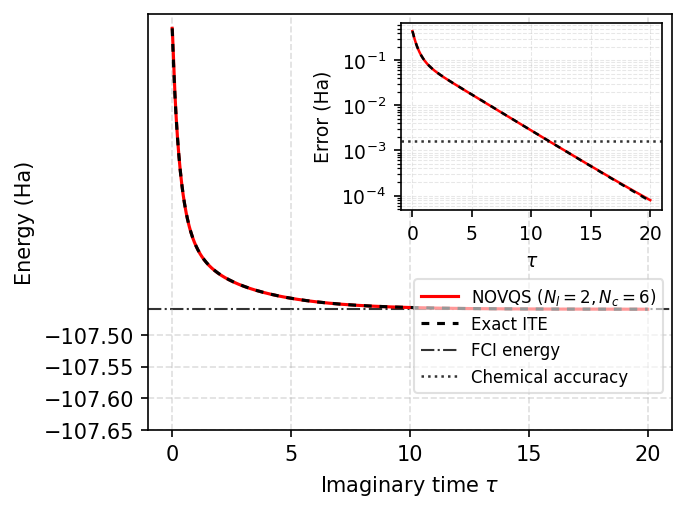

In [20]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Example input data (replace with your own data for actual use)
# time_points, energies_vqs, energies_ite, Eg
dist = 1.8
B = 1
Ns = 18
file_path = f"data/NOVQS-ITE-energies-N2-dist={dist}-Nq=12-T=20.0-dt=0.01-L=6-B={B}-Ns={Ns}-HF-Perturbation.npy"
data = jnp.load(file_path, allow_pickle=True).item()
energies_vqs = data['energies_novqs']
energies_ite = data['energies_ite']
Eg = data['Eg']
time_points = data['time_points']


# Calculate the errors
error_vqs = jnp.abs(energies_vqs - Eg)
error_ite = jnp.abs(energies_ite - Eg)

# 2. Create the figure (4.5x3.6, matching the existing code)
fig, ax = plt.subplots(figsize=(4.5, 3.6), dpi=150)

# 3. Main plot: energy evolution

# Plot VQS (points or a thin line; a line is recommended for a consistent style)
line_vqs = ax.plot(time_points, energies_vqs, '-', color='red', linewidth=1.5, 
        label=r'NOVQS ($N_l=2, N_c=6$)')

# Plot Exact ITE (solid line)
line_ite = ax.plot(time_points, energies_ite, ls=(0, (2.5, 2.5)), color='black', linewidth=1.5, 
        label='Exact ITE')


# Plot the ground-state energy reference line (red dashed line, matching the NOVQS style)
line_gs = ax.axhline(y=Eg, color='black', ls='-.', linewidth=1.0, label='FCI energy', alpha=0.8, zorder=1)

# 4. Format the main plot (match ticks, labels, and font sizes)
ax.set_xlabel('Imaginary time $\\tau$', fontsize=10)
ax.set_ylabel('Energy (Ha)', fontsize=10)
ax.set_yticks([-107.50, -107.55, -107.60, -107.65])
ax.tick_params(axis='both', which='major', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

# ==========================================
# 5. Add an inset showing the error on a logarithmic scale
# ==========================================
# Relative position [left, bottom, width, height]; place near the lower left to avoid the upper-right legend
ax_ins = ax.inset_axes([0.482, 0.53, 0.5, 0.45])

# Chemical-accuracy reference line

ax_ins.semilogy(time_points, error_vqs, '-', color='red', linewidth=1.2)
ax_ins.semilogy(time_points, error_ite, ls=(0, (2.5, 2.5)), color='black', linewidth=1.2)

line_ca = ax_ins.axhline(y=1.6e-3, color='black', linestyle=':', linewidth=1.2, label='Chemical accuracy', alpha=0.8, zorder=1)

# Format the inset
ax_ins.set_xlabel('$\\tau$', fontsize=9)
ax_ins.set_xticks([0, 5, 10, 15, 20])
ax_ins.set_ylabel('Error (Ha)', fontsize=9)
ax_ins.tick_params(axis='both', which='major', labelsize=9)
ax_ins.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)

# 1. Get all legend handles and labels from the main plot
handles, labels = ax.get_legend_handles_labels()
handles.append(line_ca)
labels.append('Chemical accuracy')
ax.legend(handles=handles, labels=labels, handlelength=2.2, loc='lower right', bbox_to_anchor=(1.0, 0.07), fontsize=8, framealpha=0.6)

# 6. Save and display
#plt.savefig(f"fig/N2-dist=1.2-ITE-NOVQS.pdf", bbox_inches='tight')
plt.show()


## Classical methods

In [ ]:
# scan distances
distances = np.arange(0.75, 2.11, 0.01)
basis = 'sto-3g'
spin = 0   # multiplicity=1 -> spin=0
charge = 0
frozen =  4 

results = {'distances': distances, 'HF': [], 'CISD': [], 'CCSD': [], 'CCSD(T)': [], 'FCI': []}

for dist in tqdm(distances, desc="Progress"):
    mol = gto.M(
        atom = f'N 0 0 0; N 0 0 {dist}',
        basis = basis,
        spin = spin,
        charge = charge,
        verbose = 0
    )

    # Hartree–Fock
    mf = scf.RHF(mol).run()
    hf_energy = mf.e_tot

    # CISD
    myci = ci.CISD(mf, frozen=frozen).run()
    cisd_energy = myci.e_tot

    # CCSD
    mycc = cc.CCSD(mf, frozen=frozen)#.run()
    if dist >= 2.0:
        mycc.diis = True
        mycc.diis_space = 12
        mycc.diis_start_cycle = 4
        mycc.conv_tol = 1e-10
        mycc.level_shift = 0.3
        mycc.max_cycle = 300
        mycc.damp = 0.2
    mycc = mycc.run()
    ccsd_energy = mycc.e_tot

    # CCSD(T)
    ccsdt_energy = mycc.e_tot + mycc.ccsd_t()

    # FCI
    ncore = frozen
    nmo = mf.mo_coeff.shape[1]
    ncas = nmo - ncore
    nelecas = mol.nelectron - 2 * ncore
    mc = mcscf.CASCI(mf, ncas, nelecas)
    mc.ncore = ncore          
    fci_energy = mc.kernel()[0]   


    results['HF'].append(hf_energy)
    results['CISD'].append(cisd_energy)
    results['CCSD'].append(ccsd_energy)
    results['CCSD(T)'].append(ccsdt_energy)
    results['FCI'].append(fci_energy)

    print("HF energy: ", hf_energy)
    print("CISD energy: ", cisd_energy)
    print("CCSD energy: ", ccsd_energy)
    print("CCSD(T) energy: ", ccsdt_energy)
    print("FCI energy: ", fci_energy)

# save
np.savez('data/N2-12_qubit-scf_energies.npz', **results)


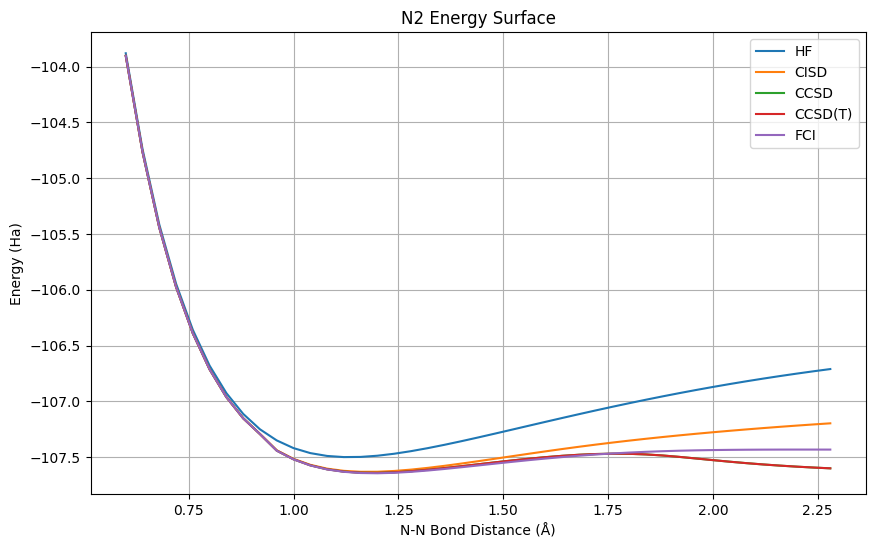

In [3]:
# load data
with np.load('data/N2-12_qubit-scf_energies.npz') as data:
    dist = data['distances']
    hf = data['HF']
    cisd = data['CISD']
    ccsd = data['CCSD']
    ccsdt = data['CCSD(T)']
    fci = data['FCI']

# draw energy surface
step = 4  
plt.figure(figsize=(10, 6))
plt.plot(dist[::step], hf[::step], label='HF')
plt.plot(dist[::step], cisd[::step], label='CISD')
plt.plot(dist[::step], ccsd[::step], label='CCSD')
plt.plot(dist[::step], ccsdt[::step], label='CCSD(T)')
plt.plot(dist[::step], fci[::step], label='FCI')
plt.xlabel('N-N Bond Distance (Å)')
plt.ylabel('Energy (Ha)')
plt.title('N2 Energy Surface')
plt.legend()
plt.grid(True)
plt.show()

## Energy surface

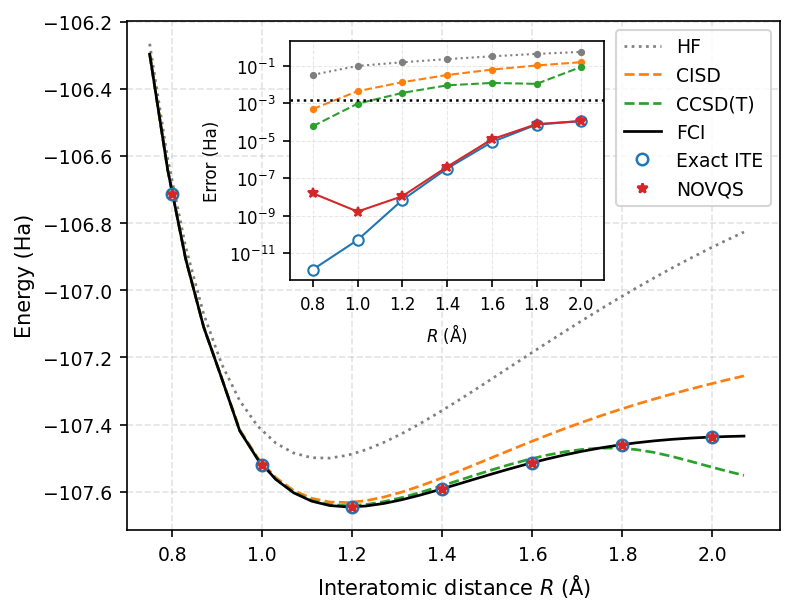

In [2]:
import numpy as np
import matplotlib.pyplot as plt

target_distances = np.array([0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0])
ite_final_energies, novqs_final_energies, ground_energies = [], [], []

for dist in target_distances:
    file_path = f"data/NOVQS-ITE-energies-N2-dist={dist}-Nq=12-T=20.0-dt=0.01-L=6-B=1-Ns=18-HF-Perturbation.npy"
    data = np.load(file_path, allow_pickle=True).item()
    ite_final_energies.append(np.asarray(data["energies_ite"]).reshape(-1)[-1])
    novqs_final_energies.append(np.asarray(data["energies_novqs"]).reshape(-1)[-1])
    ground_energies.append(float(np.asarray(data["Eg"]).squeeze()))

ite_final_energies = np.asarray(ite_final_energies)
novqs_final_energies = np.asarray(novqs_final_energies)
ground_energies = np.asarray(ground_energies)

scf_data = np.load("data/N2-12_qubit-scf_energies.npz")
scf_distances = np.asarray(scf_data["distances"])

method_info = {
    "HF": ("tab:gray", ":"),
    "CISD": ("tab:orange", "--"),
    #"CCSD": ("tab:green", "-."),
    "CCSD(T)": ("tab:green", "--"),
    "FCI": ("black", "-"),
}

fig, ax = plt.subplots(figsize=(5.4, 4.2), dpi=150)
step = 4

for method, (color, linestyle) in method_info.items():
    ax.plot(scf_distances[::step], scf_data[method][::step], color=color, linestyle=linestyle, linewidth=1.3, label=method)

ax.plot(target_distances, ite_final_energies, ls="none", marker="o", ms=5.5, mfc="white", mec="tab:blue", mew=1.2, label=r"Exact ITE", zorder=2)
ax.plot(target_distances, novqs_final_energies, ls="none", marker="*", ms=5.0, color="tab:red", mew=1.2, label=r"NOVQS", zorder=3)

ax.set_xlabel(r"Interatomic distance $R$ ($\mathrm{\AA}$)", fontsize=10)
ax.set_ylabel("Energy (Ha)", fontsize=10)
ax.set_xlim(0.7, 2.15)
ax.tick_params(axis="both", labelsize=9)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(fontsize=9, ncol=1, loc="best", framealpha=0.8)

ax_ins = ax.inset_axes([0.25, 0.49, 0.48, 0.47])
plot_floor = 1e-12

for method, (color, linestyle) in method_info.items():
    if method == "FCI":
        continue
    energies = np.interp(target_distances, scf_distances, scf_data[method])
    errors = np.abs(energies - ground_energies)
    ax_ins.plot(target_distances, np.maximum(errors, plot_floor), color=color, ls=linestyle, marker=".", ms=5, lw=1)

ite_errors = np.abs(ite_final_energies - ground_energies)
novqs_errors = np.abs(novqs_final_energies - ground_energies)

ax_ins.plot(target_distances, ite_errors, color="tab:blue", marker="o", ms=5, mfc="white", lw=1)
ax_ins.plot(target_distances, novqs_errors, color="tab:red", marker="*", ms=5, lw=1)
ax_ins.axhline(1.6e-3, color="black", ls=":", lw=1.2)

ax_ins.set_yscale("log")
ax_ins.set_xlim(0.7, 2.1)
ax_ins.set_xticks([0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0])
ax_ins.set_xlabel(r"$R$ ($\mathrm{\AA}$)", fontsize=8)
ax_ins.set_ylabel(r"Error (Ha)", fontsize=8)
ax_ins.tick_params(axis="both", labelsize=8)
ax_ins.grid(True, which="both", ls="--", lw=0.5, alpha=0.3)

plt.tight_layout()
#plt.savefig("fig/N2-energy-curve.pdf", bbox_inches="tight")
plt.show()